# 01 — Upper Bound Back-test: Sequential FCR-D Bidding (Perfect Forecasts)

This notebook computes the **upper bound** on revenue for a simulated 1 MW BTM battery portfolio
participating in the FCR-D up and down markets (DK2) via sequential day-ahead auctions (early + late).

**All forecasts are perfect** — actual realised values are fed directly into the MILP.
No noise, no randomness in predictions. This gives the theoretical maximum revenue.

Noise / sensitivity analysis belongs in `02_Sensitivity.ipynb`.

### Model summary
- Two MILPs per day: **Early auction** (00:00 DA) and **Late auction** (17:00 DA)
- Objectives: minimise net electricity cost while maximising FCR-D reservation revenue
- Competing trade-offs: self-consumption + arbitrage vs. ancillary services capacity reservation
- Solver: HiGHS via Pyomo `appsi_highs`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, os, time
from datetime import date as dt_date

import pyomo.environ as pyo

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.max_open_warning': 0, 'figure.dpi': 120})

print('All imports OK')

All imports OK


## 1. Configuration & Parameters (Table 2)

In [2]:
# ── Paths (adjust to your layout) ─────────────────────────────────────────
BASE_DIR       = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_OUT_DIR   = os.path.join(BASE_DIR, 'data', 'data_out')
FIGURES_DIR    = os.path.join(BASE_DIR, 'figures')
COMBINED_CSV   = os.path.join(DATA_OUT_DIR, 'combined_2025_with_frequency.csv')
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Portfolio parameters (Table 2) ────────────────────────────────────────
N_EC           = 10        # number of energy communities
MAX_POWER_EC   = 100       # kW per EC battery
CAPACITY_EC    = 200       # kWh per EC battery
ETA            = 0.95      # one-way efficiency; round-trip = eta^2
SOC_INIT_FRAC  = 0.50      # initial & terminal SOC fraction
P_MIN_BID      = 100       # kW minimum FCR-D bid in DK2
T_SUSTAIN      = 0.5       # hours sustain duration
T_MAX          = 24        # hours per day

# Derived
P_MAX_PORTFOLIO = N_EC * MAX_POWER_EC   # 1000 kW
S_MAX_PORTFOLIO = N_EC * CAPACITY_EC     # 2000 kWh
SOC_INIT_KWH    = SOC_INIT_FRAC * CAPACITY_EC  # 100 kWh per EC

# ── Synthetic portfolio (deterministic seed) ──────────────────────────────
RNG_SEED       = 42
PROB_B_TYPE    = 0.60
SCALE_MU       = 1.0
SCALE_SIGMA    = 1.0

ORE_TO_DKK     = 1.0 / 100.0   # prices in CSV are øre/kWh → DKK/kWh

print(f'Portfolio: {N_EC} ECs × {MAX_POWER_EC} kW / {CAPACITY_EC} kWh = '
      f'{P_MAX_PORTFOLIO} kW / {S_MAX_PORTFOLIO} kWh')

Portfolio: 10 ECs × 100 kW / 200 kWh = 1000 kW / 2000 kWh


## 2. Load & prepare data

In [3]:
# ── Load raw CSV ──────────────────────────────────────────────────────────
df_raw = pd.read_csv(COMBINED_CSV, parse_dates=['hour_utc'])
df_raw = df_raw.sort_values(['hour_utc', 'ec_id']).reset_index(drop=True)
print(f'Loaded {len(df_raw)} rows  |  ec_ids: {sorted(df_raw["ec_id"].unique())}  |  '
      f'{df_raw["hour_utc"].min()} → {df_raw["hour_utc"].max()}')

# ── Separate market data (one row per hour) from EC profiles ──────────────
# Market columns are the same for both ec_id rows in each hour;
# take from the first row per hour.
df_market = df_raw.groupby('hour_utc').first().reset_index()

# Convert prices from øre/kWh → DKK/kWh
price_cols_ore = [
    'buy_price_inkl_vat_ore_kwh',
    'sell_price_inkl_vat_ore_kwh',
    'price_ore_kwh_fcr_d_upp__d_1_early',
    'price_ore_kwh_fcr_d_upp__d_1_late',
    'price_ore_kwh_fcr_d_ned__d_1_early',
    'price_ore_kwh_fcr_d_ned__d_1_late',
]
for col in price_cols_ore:
    df_market[col.replace('ore', 'dkk')] = df_market[col] * ORE_TO_DKK

# Rename for convenience
df_market.rename(columns={
    'buy_price_inkl_vat_ore_kwh':           'buy_ore',
    'sell_price_inkl_vat_ore_kwh':          'sell_ore',
}, inplace=True)

# DKK price columns (created above)
COL_BUY       = 'buy_price_inkl_vat_dkk_kwh'
COL_SELL      = 'sell_price_inkl_vat_dkk_kwh'
COL_UP_EARLY  = 'price_dkk_kwh_fcr_d_upp__d_1_early'
COL_UP_LATE   = 'price_dkk_kwh_fcr_d_upp__d_1_late'
COL_DOWN_EARLY= 'price_dkk_kwh_fcr_d_ned__d_1_early'
COL_DOWN_LATE = 'price_dkk_kwh_fcr_d_ned__d_1_late'
COL_ACT_UP    = 'y_act_fcrd_up'
COL_ACT_DOWN  = 'y_act_fcrd_down'

# Buyback price = max(early, late) per direction
df_market['buyback_up']   = df_market[[COL_UP_EARLY,   COL_UP_LATE]].max(axis=1)
df_market['buyback_down'] = df_market[[COL_DOWN_EARLY, COL_DOWN_LATE]].max(axis=1)

# Acceptance flag: accepted where price > 0 (Assumption A1)
df_market['y_acc_up']   = (df_market[COL_UP_EARLY]   > 0).astype(float)
df_market['y_acc_down'] = (df_market[COL_DOWN_EARLY] > 0).astype(float)

df_market['date'] = df_market['hour_utc'].dt.date

print(f'Market data: {len(df_market)} hours')
print(f'Sample buy price (DKK/kWh): {df_market[COL_BUY].iloc[0]:.4f}')
print(f'Sample FCR-D Up early (DKK/kWh): {df_market[COL_UP_EARLY].iloc[0]:.4f}')

Loaded 17520 rows  |  ec_ids: ['b', 's']  |  2025-01-01 00:00:00+00:00 → 2025-12-31 23:00:00+00:00
Market data: 8760 hours
Sample buy price (DKK/kWh): 0.2900
Sample FCR-D Up early (DKK/kWh): 0.0082


In [4]:
# ── Extract base EC profiles (b-type and s-type) per hour ────────────────
# The CSV has one row per (hour, ec_id). Pivot to get daily profile shapes.
df_b = df_raw[df_raw['ec_id'] == 'b'][['hour_utc', 'consumption', 'pv_production_kwh']].copy()
df_b = df_b.rename(columns={'consumption': 'load_b', 'pv_production_kwh': 'pv_b'})

df_s = df_raw[df_raw['ec_id'] == 's'][['hour_utc', 'consumption', 'pv_production_kwh']].copy()
df_s = df_s.rename(columns={'consumption': 'load_s', 'pv_production_kwh': 'pv_s'})

# Merge onto market data
df_all = df_market.merge(df_b, on='hour_utc', how='left')
df_all = df_all.merge(df_s, on='hour_utc', how='left')

# Fill any NaN profiles with 0
for c in ['load_b', 'pv_b', 'load_s', 'pv_s']:
    df_all[c] = df_all[c].fillna(0.0)

print(f'Combined data: {len(df_all)} rows')
print(df_all[['hour_utc', 'load_b', 'pv_b', 'load_s', 'pv_s',
              COL_BUY, COL_UP_EARLY]].head(5))

Combined data: 8760 rows
                   hour_utc  load_b  pv_b  load_s  pv_s  \
0 2025-01-01 00:00:00+00:00    0.00   0.0     0.0   0.0   
1 2025-01-01 01:00:00+00:00    5.50   0.0     7.6   0.0   
2 2025-01-01 02:00:00+00:00    7.90   0.0     9.7   0.0   
3 2025-01-01 03:00:00+00:00    6.65   0.0     8.3   0.0   
4 2025-01-01 04:00:00+00:00    6.05   0.0     8.3   0.0   

   buy_price_inkl_vat_dkk_kwh  price_dkk_kwh_fcr_d_upp__d_1_early  
0                    0.289988                            0.008206  
1                    0.289988                            0.008206  
2                    0.285325                            0.008952  
3                    0.281700                            0.011488  
4                    0.293250                            0.011190  


## 3. Portfolio construction (deterministic)

In [5]:
def generate_portfolio(n_ec, prob_b, scale_mu, scale_sigma, seed):
    """
    Deterministic synthetic portfolio.
    Each EC is assigned b-type or s-type, with a positive scale factor.
    """
    rng = np.random.default_rng(seed)
    ec_types = []
    scale_factors = []
    for _ in range(n_ec):
        ec_types.append('b' if rng.random() < prob_b else 's')
        while True:
            s = rng.normal(scale_mu, scale_sigma)
            if s > 0:
                scale_factors.append(s)
                break
    return ec_types, np.array(scale_factors)


ec_types, scale_factors = generate_portfolio(
    N_EC, PROB_B_TYPE, SCALE_MU, SCALE_SIGMA, RNG_SEED
)

n_b = sum(t == 'b' for t in ec_types)
n_s = N_EC - n_b
print(f'Portfolio: {n_b} b-type, {n_s} s-type')
print(f'Scale factors: {np.round(scale_factors, 3)}')

Portfolio: 4 b-type, 6 s-type
Scale factors: [1.75  1.128 0.983 1.879 1.066 1.468 1.369 1.878 0.815 2.223]


In [6]:
def get_ec_profiles(df_day, ec_types, scale_factors):
    """
    Build (N_EC, 24) arrays for load and PV from the day's base profiles.
    Each EC gets its type's base profile × its scale factor.
    """
    n_ec = len(ec_types)
    loads = np.zeros((n_ec, 24))
    pvs   = np.zeros((n_ec, 24))
    
    load_b = df_day['load_b'].values
    pv_b   = df_day['pv_b'].values
    load_s = df_day['load_s'].values
    pv_s   = df_day['pv_s'].values
    
    for e in range(n_ec):
        if ec_types[e] == 'b':
            loads[e] = load_b * scale_factors[e]
            pvs[e]   = pv_b   * scale_factors[e]
        else:
            loads[e] = load_s * scale_factors[e]
            pvs[e]   = pv_s   * scale_factors[e]
    
    return loads, pvs

print('get_ec_profiles() defined')

get_ec_profiles() defined


## 4. MILP Model: Early Auction (§2.1)

Perfect forecasts: actual values used as-is.

In [7]:
def build_early_model(loads, pvs, buy_price, sell_price,
                      fcrd_up_price, fcrd_down_price,
                      act_frac_up, act_frac_down,
                      y_acc_up, y_acc_down):
    """
    Build the early auction MILP (§2.1).
    loads, pvs: (N_EC, 24).  All price/frac arrays: (24,).
    All values are PERFECT (actual) — no forecast error.
    """
    n_ec  = loads.shape[0]
    b_max = MAX_POWER_EC
    s_max = CAPACITY_EC
    eta   = ETA
    soc0  = SOC_INIT_KWH
    p_min = P_MIN_BID
    p_max = P_MAX_PORTFOLIO
    t_sus = T_SUSTAIN
    E = range(n_ec)
    T = range(T_MAX)

    m = pyo.ConcreteModel('Early')
    m.E = pyo.Set(initialize=E)
    m.T = pyo.Set(initialize=T)

    # Decision variables (all >= 0 unless stated)
    m.p_im       = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)
    m.p_ex       = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)
    m.b_ch       = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)
    m.b_dis      = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)
    m.SOC        = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)
    m.p_up_res   = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)
    m.p_down_res = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)
    m.p_up_act   = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)
    m.p_down_act = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)
    m.p_net      = pyo.Var(m.E, m.T, within=pyo.Reals)
    m.z_up       = pyo.Var(m.T, within=pyo.Binary)
    m.z_down     = pyo.Var(m.T, within=pyo.Binary)

    # ── Objective (m2a) ───────────────────────────────────────────────────
    def obj_rule(m):
        return sum(
            buy_price[t]  * (sum(m.p_im[e,t] for e in E) - sum(m.p_down_act[e,t] for e in E))
          - sell_price[t] * (sum(m.p_ex[e,t] for e in E) - sum(m.p_up_act[e,t]   for e in E))
          - fcrd_up_price[t]   * sum(m.p_up_res[e,t]   for e in E)
          - fcrd_down_price[t] * sum(m.p_down_res[e,t] for e in E)
          for t in T)
    m.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

    # (m1b) p_net = p_im - p_ex
    m.c_net = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_net[e,t] - m.p_im[e,t] + m.p_ex[e,t] == 0)

    # (c2i) Power balance:  p_net + PV - D - (b_ch + p_down_act) + (b_dis + p_up_act) = 0
    m.c_pb = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_net[e,t] + pvs[e,t] - loads[e,t]
            - (m.b_ch[e,t] + m.p_down_act[e,t])
            + (m.b_dis[e,t] + m.p_up_act[e,t]) == 0)

    # (c3bup/down) Activation = y_acc * y_act * reservation
    m.c_act_up = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_up_act[e,t] == y_acc_up[t] * act_frac_up[t] * m.p_up_res[e,t])
    m.c_act_dn = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_down_act[e,t] == y_acc_down[t] * act_frac_down[t] * m.p_down_res[e,t])

    # (m2k) SOC at t=0
    m.c_soc0 = pyo.Constraint(m.E,
        rule=lambda m,e: m.SOC[e,0] == soc0
            + eta * (m.b_ch[e,0] + m.p_down_act[e,0])
            - (1.0/eta) * (m.b_dis[e,0] + m.p_up_act[e,0]))

    # (m2j) SOC dynamics for t in 1..T_MAX-2
    def soc_dyn(m, e, t):
        if t == 0 or t == T_MAX - 1:
            return pyo.Constraint.Skip
        return m.SOC[e,t] == m.SOC[e,t-1] \
            + eta * (m.b_ch[e,t] + m.p_down_act[e,t]) \
            - (1.0/eta) * (m.b_dis[e,t] + m.p_up_act[e,t])
    m.c_soc_dyn = pyo.Constraint(m.E, m.T, rule=soc_dyn)

    # (c1l) Terminal SOC = soc0
    m.c_soc_end = pyo.Constraint(m.E,
        rule=lambda m,e: m.SOC[e, T_MAX-1] == soc0)

    # (m13 up)  SOC >= y_acc * T_sus / eta * p_up_res
    m.c_sus_up = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.SOC[e,t] >= y_acc_up[t] * t_sus / eta * m.p_up_res[e,t])

    # (m13 down) S_max - SOC >= y_acc * T_sus * eta * p_down_res
    m.c_sus_dn = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: s_max - m.SOC[e,t] >= y_acc_down[t] * t_sus * eta * m.p_down_res[e,t])

    # (c1m) b_ch + p_down_res <= b_max
    m.c_ch_lim = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.b_ch[e,t] + m.p_down_res[e,t] <= b_max)

    # (c3c) b_dis + p_up_res <= b_max
    m.c_dis_lim = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.b_dis[e,t] + m.p_up_res[e,t] <= b_max)

    # (c3d) SOC >= p_up_res
    m.c_soc_up = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.SOC[e,t] >= m.p_up_res[e,t])

    # (c3d) S_max - SOC >= p_down_res
    m.c_soc_dn = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: s_max - m.SOC[e,t] >= m.p_down_res[e,t])

    # SOC upper bound
    m.c_soc_cap = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.SOC[e,t] <= s_max)

    # (m1up/m1down) Min bid size MILP
    m.c_bid_up_lo = pyo.Constraint(m.T,
        rule=lambda m,t: p_min * m.z_up[t] <= sum(m.p_up_res[e,t] for e in E))
    m.c_bid_up_hi = pyo.Constraint(m.T,
        rule=lambda m,t: sum(m.p_up_res[e,t] for e in E) <= p_max * m.z_up[t])
    m.c_bid_dn_lo = pyo.Constraint(m.T,
        rule=lambda m,t: p_min * m.z_down[t] <= sum(m.p_down_res[e,t] for e in E))
    m.c_bid_dn_hi = pyo.Constraint(m.T,
        rule=lambda m,t: sum(m.p_down_res[e,t] for e in E) <= p_max * m.z_down[t])

    return m

print('build_early_model() defined')

build_early_model() defined


## 5. MILP Model: Late Auction (§2.2)

Takes accepted early bids as given. Can top-up or cancel (buy back) per hour.

In [8]:
def build_late_model(loads, pvs, buy_price, sell_price,
                     fcrd_up_early_price, fcrd_down_early_price,
                     fcrd_up_late_price, fcrd_down_late_price,
                     buyback_up_price, buyback_down_price,
                     act_frac_up, act_frac_down,
                     y_acc_up, y_acc_down,
                     early_up_acc, early_down_acc):
    """
    Build the late auction MILP (§2.2).
    early_up_acc, early_down_acc: (N_EC, 24) accepted early bids.
    """
    n_ec  = loads.shape[0]
    b_max = MAX_POWER_EC
    s_max = CAPACITY_EC
    eta   = ETA
    soc0  = SOC_INIT_KWH
    p_min = P_MIN_BID
    p_max = P_MAX_PORTFOLIO
    t_sus = T_SUSTAIN
    E = range(n_ec)
    T = range(T_MAX)

    m = pyo.ConcreteModel('Late')
    m.E = pyo.Set(initialize=E)
    m.T = pyo.Set(initialize=T)

    # Variables
    m.p_im       = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)
    m.p_ex       = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)
    m.b_ch       = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)
    m.b_dis      = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)
    m.SOC        = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)
    m.p_net      = pyo.Var(m.E, m.T, within=pyo.Reals)
    m.p_up_res   = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)  # final total
    m.p_down_res = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)
    m.p_up_act   = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)
    m.p_down_act = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)
    m.a_up       = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)  # top-up
    m.a_down     = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)
    m.c_up       = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)  # cancel
    m.c_down     = pyo.Var(m.E, m.T, within=pyo.NonNegativeReals)
    m.w_up       = pyo.Var(m.T, within=pyo.Binary)  # 1 if topping up
    m.w_down     = pyo.Var(m.T, within=pyo.Binary)
    m.z_up       = pyo.Var(m.T, within=pyo.Binary)  # 1 if final total > 0
    m.z_down     = pyo.Var(m.T, within=pyo.Binary)

    # Link final = early_accepted + top-up - cancel
    m.c_link_up = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_up_res[e,t] == early_up_acc[e,t] + m.a_up[e,t] - m.c_up[e,t])
    m.c_link_dn = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_down_res[e,t] == early_down_acc[e,t] + m.a_down[e,t] - m.c_down[e,t])

    # ── Objective (m2a late) ──────────────────────────────────────────────
    def obj_rule(m):
        return sum(
            buy_price[t]  * (sum(m.p_im[e,t] for e in E) - sum(m.p_down_act[e,t] for e in E))
          - sell_price[t] * (sum(m.p_ex[e,t] for e in E) - sum(m.p_up_act[e,t]   for e in E))
          - fcrd_up_early_price[t]   * sum(early_up_acc[e,t]  for e in E)
          - fcrd_down_early_price[t] * sum(early_down_acc[e,t] for e in E)
          + buyback_up_price[t]   * sum(m.c_up[e,t]   for e in E)
          + buyback_down_price[t] * sum(m.c_down[e,t] for e in E)
          - fcrd_up_late_price[t]   * sum(m.a_up[e,t]   for e in E)
          - fcrd_down_late_price[t] * sum(m.a_down[e,t] for e in E)
          for t in T)
    m.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

    # ── Same base constraints ─────────────────────────────────────────────
    m.c_net = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_net[e,t] - m.p_im[e,t] + m.p_ex[e,t] == 0)
    m.c_pb = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_net[e,t] + pvs[e,t] - loads[e,t]
            - (m.b_ch[e,t] + m.p_down_act[e,t])
            + (m.b_dis[e,t] + m.p_up_act[e,t]) == 0)
    m.c_act_up = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_up_act[e,t] == y_acc_up[t]*act_frac_up[t]*m.p_up_res[e,t])
    m.c_act_dn = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_down_act[e,t] == y_acc_down[t]*act_frac_down[t]*m.p_down_res[e,t])

    m.c_soc0 = pyo.Constraint(m.E,
        rule=lambda m,e: m.SOC[e,0] == soc0
            + eta*(m.b_ch[e,0]+m.p_down_act[e,0])
            - (1.0/eta)*(m.b_dis[e,0]+m.p_up_act[e,0]))
    def soc_dyn(m,e,t):
        if t==0 or t==T_MAX-1: return pyo.Constraint.Skip
        return m.SOC[e,t] == m.SOC[e,t-1] \
            + eta*(m.b_ch[e,t]+m.p_down_act[e,t]) \
            - (1.0/eta)*(m.b_dis[e,t]+m.p_up_act[e,t])
    m.c_soc_dyn = pyo.Constraint(m.E, m.T, rule=soc_dyn)
    m.c_soc_end = pyo.Constraint(m.E, rule=lambda m,e: m.SOC[e,T_MAX-1]==soc0)

    m.c_sus_up = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.SOC[e,t] >= y_acc_up[t]*t_sus/eta*m.p_up_res[e,t])
    m.c_sus_dn = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: s_max - m.SOC[e,t] >= y_acc_down[t]*t_sus*eta*m.p_down_res[e,t])

    m.c_ch_lim = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.b_ch[e,t] + m.p_down_res[e,t] <= b_max)
    m.c_dis_lim = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.b_dis[e,t] + m.p_up_res[e,t] <= b_max)
    m.c_soc_up = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.SOC[e,t] >= m.p_up_res[e,t])
    m.c_soc_dn = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: s_max - m.SOC[e,t] >= m.p_down_res[e,t])
    m.c_soc_cap = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.SOC[e,t] <= s_max)

    # Min bid for top-ups
    m.c_tu_up_lo = pyo.Constraint(m.T,
        rule=lambda m,t: p_min*m.w_up[t] <= sum(m.a_up[e,t] for e in E))
    m.c_tu_up_hi = pyo.Constraint(m.T,
        rule=lambda m,t: sum(m.a_up[e,t] for e in E) <= p_max*m.w_up[t])
    m.c_tu_dn_lo = pyo.Constraint(m.T,
        rule=lambda m,t: p_min*m.w_down[t] <= sum(m.a_down[e,t] for e in E))
    m.c_tu_dn_hi = pyo.Constraint(m.T,
        rule=lambda m,t: sum(m.a_down[e,t] for e in E) <= p_max*m.w_down[t])

    # Min bid for final total reservation
    m.c_fin_up_lo = pyo.Constraint(m.T,
        rule=lambda m,t: p_min*m.z_up[t] <= sum(m.p_up_res[e,t] for e in E))
    m.c_fin_up_hi = pyo.Constraint(m.T,
        rule=lambda m,t: sum(m.p_up_res[e,t] for e in E) <= p_max*m.z_up[t])
    m.c_fin_dn_lo = pyo.Constraint(m.T,
        rule=lambda m,t: p_min*m.z_down[t] <= sum(m.p_down_res[e,t] for e in E))
    m.c_fin_dn_hi = pyo.Constraint(m.T,
        rule=lambda m,t: sum(m.p_down_res[e,t] for e in E) <= p_max*m.z_down[t])

    # Cannot cancel and top-up simultaneously
    m.c_nosim_up = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.c_up[e,t] <= early_up_acc[e,t]*(1-m.w_up[t]))
    m.c_nosim_dn = pyo.Constraint(m.E, m.T,
        rule=lambda m,e,t: m.c_down[e,t] <= early_down_acc[e,t]*(1-m.w_down[t]))

    return m

print('build_late_model() defined')

build_late_model() defined


## 6. Solver & helpers

In [9]:
from pyomo.environ import SolverFactory

SOLVER = 'appsi_highs'

def solve_model(model):
    res = SolverFactory(SOLVER).solve(model, tee=False)
    tc = res.solver.termination_condition
    if tc not in (pyo.TerminationCondition.optimal, pyo.TerminationCondition.feasible):
        raise RuntimeError(f'Solver: {tc}')
    return res

def xvar2d(var, n, t=T_MAX):
    a = np.zeros((n, t))
    for e in range(n):
        for h in range(t):
            a[e,h] = pyo.value(var[e,h])
    return a

print('Solver ready')

Solver ready


## 7. Daily solve (Early → Late, perfect forecasts)

In [10]:
def solve_day(date_val, df_day, loads, pvs, run_base=True):
    """
    Solve sequential auction for one day with PERFECT forecasts.
    df_day: one-row-per-hour market data for this day (24 rows).
    loads, pvs: (N_EC, 24).
    """
    n_ec = loads.shape[0]

    buy   = df_day[COL_BUY].values
    sell  = df_day[COL_SELL].values
    up_e  = df_day[COL_UP_EARLY].values
    dn_e  = df_day[COL_DOWN_EARLY].values
    up_l  = df_day[COL_UP_LATE].values
    dn_l  = df_day[COL_DOWN_LATE].values
    af_u  = df_day[COL_ACT_UP].values
    af_d  = df_day[COL_ACT_DOWN].values
    ya_u  = df_day['y_acc_up'].values
    ya_d  = df_day['y_acc_down'].values
    bb_u  = df_day['buyback_up'].values
    bb_d  = df_day['buyback_down'].values

    # ── Early auction ─────────────────────────────────────────────────────
    me = build_early_model(loads, pvs, buy, sell, up_e, dn_e, af_u, af_d, ya_u, ya_d)
    solve_model(me)

    early_up  = xvar2d(me.p_up_res,   n_ec)
    early_dn  = xvar2d(me.p_down_res, n_ec)
    # Assumption A1: all accepted
    early_up_acc = early_up.copy()
    early_dn_acc = early_dn.copy()

    # ── Late auction ──────────────────────────────────────────────────────
    ml = build_late_model(loads, pvs, buy, sell,
                          up_e, dn_e, up_l, dn_l, bb_u, bb_d,
                          af_u, af_d, ya_u, ya_d,
                          early_up_acc, early_dn_acc)
    solve_model(ml)

    # Extract final results
    fin_up  = xvar2d(ml.p_up_res,   n_ec)
    fin_dn  = xvar2d(ml.p_down_res, n_ec)
    fin_im  = xvar2d(ml.p_im,       n_ec)
    fin_ex  = xvar2d(ml.p_ex,       n_ec)
    fin_soc = xvar2d(ml.SOC,        n_ec)
    fin_bch = xvar2d(ml.b_ch,       n_ec)
    fin_bdis= xvar2d(ml.b_dis,      n_ec)
    fin_uact= xvar2d(ml.p_up_act,   n_ec)
    fin_dact= xvar2d(ml.p_down_act, n_ec)
    tu_up   = xvar2d(ml.a_up,       n_ec)
    tu_dn   = xvar2d(ml.a_down,     n_ec)
    cn_up   = xvar2d(ml.c_up,       n_ec)
    cn_dn   = xvar2d(ml.c_down,     n_ec)

    # Aggregate across ECs
    A = lambda x: x.sum(axis=0)

    # Revenue components
    import_cost = (buy * (A(fin_im) - A(fin_dact))).sum()
    export_rev  = (sell * (A(fin_ex) - A(fin_uact))).sum()

    fcrd_up_early_rev   = (up_e * A(early_up_acc)).sum()
    fcrd_dn_early_rev   = (dn_e * A(early_dn_acc)).sum()
    fcrd_up_late_rev    = (up_l * A(tu_up)).sum()
    fcrd_dn_late_rev    = (dn_l * A(tu_dn)).sum()
    buyback_up_cost     = (bb_u * A(cn_up)).sum()
    buyback_dn_cost     = (bb_d * A(cn_dn)).sum()

    r = {
        'date': date_val,
        'net_energy_cost': import_cost - export_rev,
        'import_cost': import_cost,
        'export_rev': export_rev,
        'fcrd_up_early_rev':  fcrd_up_early_rev,
        'fcrd_dn_early_rev':  fcrd_dn_early_rev,
        'fcrd_up_late_rev':   fcrd_up_late_rev,
        'fcrd_dn_late_rev':   fcrd_dn_late_rev,
        'buyback_up_cost':    buyback_up_cost,
        'buyback_dn_cost':    buyback_dn_cost,
        'fcrd_up_net':  fcrd_up_early_rev  + fcrd_up_late_rev  - buyback_up_cost,
        'fcrd_dn_net':  fcrd_dn_early_rev  + fcrd_dn_late_rev  - buyback_dn_cost,
        # Hourly vectors for plots
        'early_up_res': A(early_up), 'early_dn_res': A(early_dn),
        'final_up_res': A(fin_up),   'final_dn_res': A(fin_dn),
        'topup_up': A(tu_up),  'topup_dn': A(tu_dn),
        'cancel_up': A(cn_up), 'cancel_dn': A(cn_dn),
        'soc': A(fin_soc), 'b_ch': A(fin_bch), 'b_dis': A(fin_bdis),
        'p_im': A(fin_im), 'p_ex': A(fin_ex),
    }
    r['total_fcrd_rev'] = r['fcrd_up_net'] + r['fcrd_dn_net']

    # ── Base case: battery only (no FCR-D) ────────────────────────────────
    if run_base:
        z24 = np.zeros(T_MAX)
        mb = build_early_model(loads, pvs, buy, sell, z24, z24, af_u, af_d, z24, z24)
        solve_model(mb)
        base_im = xvar2d(mb.p_im, n_ec).sum(axis=0)
        base_ex = xvar2d(mb.p_ex, n_ec).sum(axis=0)
        r['base_energy_cost'] = (buy * base_im - sell * base_ex).sum()

        # No-battery baseline
        net_load = loads.sum(axis=0) - pvs.sum(axis=0)
        r['no_battery_cost'] = (buy * np.maximum(net_load, 0)
                                - sell * np.maximum(-net_load, 0)).sum()

    return r

print('solve_day() defined')

solve_day() defined


## 8. Single day example: May 10, 2025

In [11]:
example_date = dt_date(2025, 5, 10)

df_day = df_all[df_all['date'] == example_date].sort_values('hour_utc').reset_index(drop=True)
assert len(df_day) == 24, f'Expected 24 hours, got {len(df_day)} for {example_date}'

loads_day, pvs_day = get_ec_profiles(df_day, ec_types, scale_factors)

res = solve_day(example_date, df_day, loads_day, pvs_day)

print(f'\n=== {example_date} (perfect forecasts) ===')
print(f'No battery cost:        {res["no_battery_cost"]:>10.1f} DKK')
print(f'Base energy cost:       {res["base_energy_cost"]:>10.1f} DKK')
print(f'Net energy cost (FCRD): {res["net_energy_cost"]:>10.1f} DKK')
print(f'FCR-D Up net:           {res["fcrd_up_net"]:>10.1f} DKK')
print(f'FCR-D Down net:         {res["fcrd_dn_net"]:>10.1f} DKK')
print(f'Total FCR-D:            {res["total_fcrd_rev"]:>10.1f} DKK')


=== 2025-05-10 (perfect forecasts) ===
No battery cost:            3293.8 DKK
Base energy cost:           -409.3 DKK
Net energy cost (FCRD):     -261.0 DKK
FCR-D Up net:               1696.1 DKK
FCR-D Down net:              306.3 DKK
Total FCR-D:                2002.4 DKK


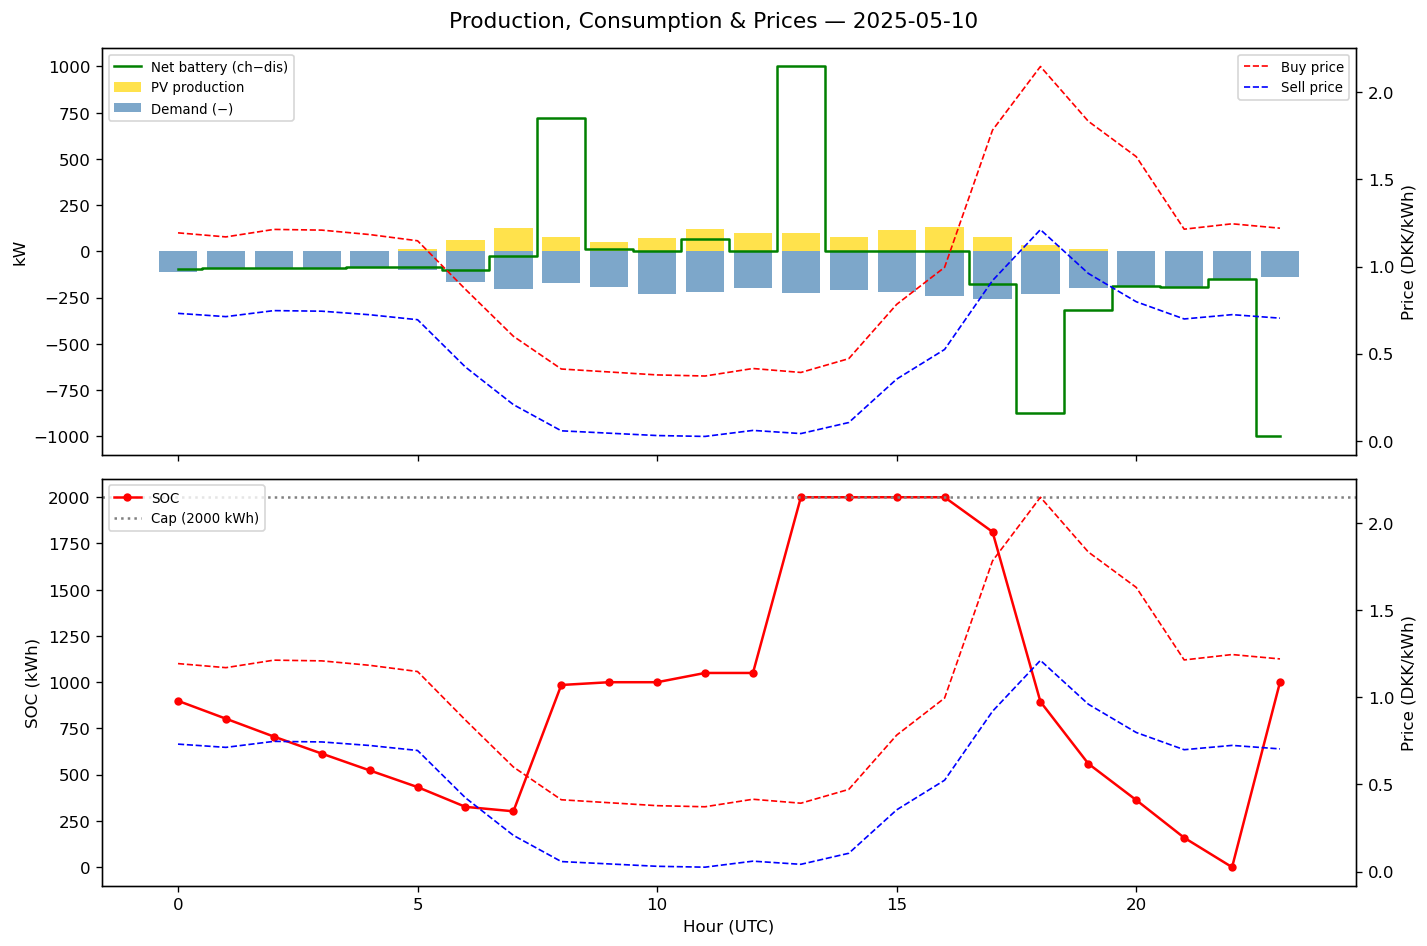

In [12]:
# ── Figure 2: Arbitrage view ─────────────────────────────────────────────
hours = np.arange(24)
buy_p  = df_day[COL_BUY].values
sell_p = df_day[COL_SELL].values

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle(f'Production, Consumption & Prices — {example_date}', fontsize=13)

ax = axes[0]
agg_pv   = pvs_day.sum(axis=0)
agg_load = loads_day.sum(axis=0)
net_batt = res['b_ch'] - res['b_dis']
ax.bar(hours, agg_pv, color='gold', alpha=0.7, label='PV production')
ax.bar(hours, -agg_load, color='steelblue', alpha=0.7, label='Demand (−)')
ax.step(hours, net_batt, color='green', lw=1.5, where='mid', label='Net battery (ch−dis)')
ax.set_ylabel('kW')
ax.legend(loc='upper left', fontsize=8)
ax2 = ax.twinx()
ax2.plot(hours, buy_p, 'r--', lw=1, label='Buy price')
ax2.plot(hours, sell_p, 'b--', lw=1, label='Sell price')
ax2.set_ylabel('Price (DKK/kWh)')
ax2.legend(loc='upper right', fontsize=8)

ax = axes[1]
ax.plot(hours, res['soc'], 'r-o', ms=4, label='SOC')
ax.axhline(S_MAX_PORTFOLIO, color='grey', ls=':', label=f'Cap ({S_MAX_PORTFOLIO} kWh)')
ax.set_ylabel('SOC (kWh)'); ax.set_xlabel('Hour (UTC)')
ax.legend(loc='upper left', fontsize=8)
ax3 = ax.twinx()
ax3.plot(hours, buy_p, 'r--', lw=1); ax3.plot(hours, sell_p, 'b--', lw=1)
ax3.set_ylabel('Price (DKK/kWh)')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'arbitrage.png'), dpi=150, bbox_inches='tight')
plt.show()

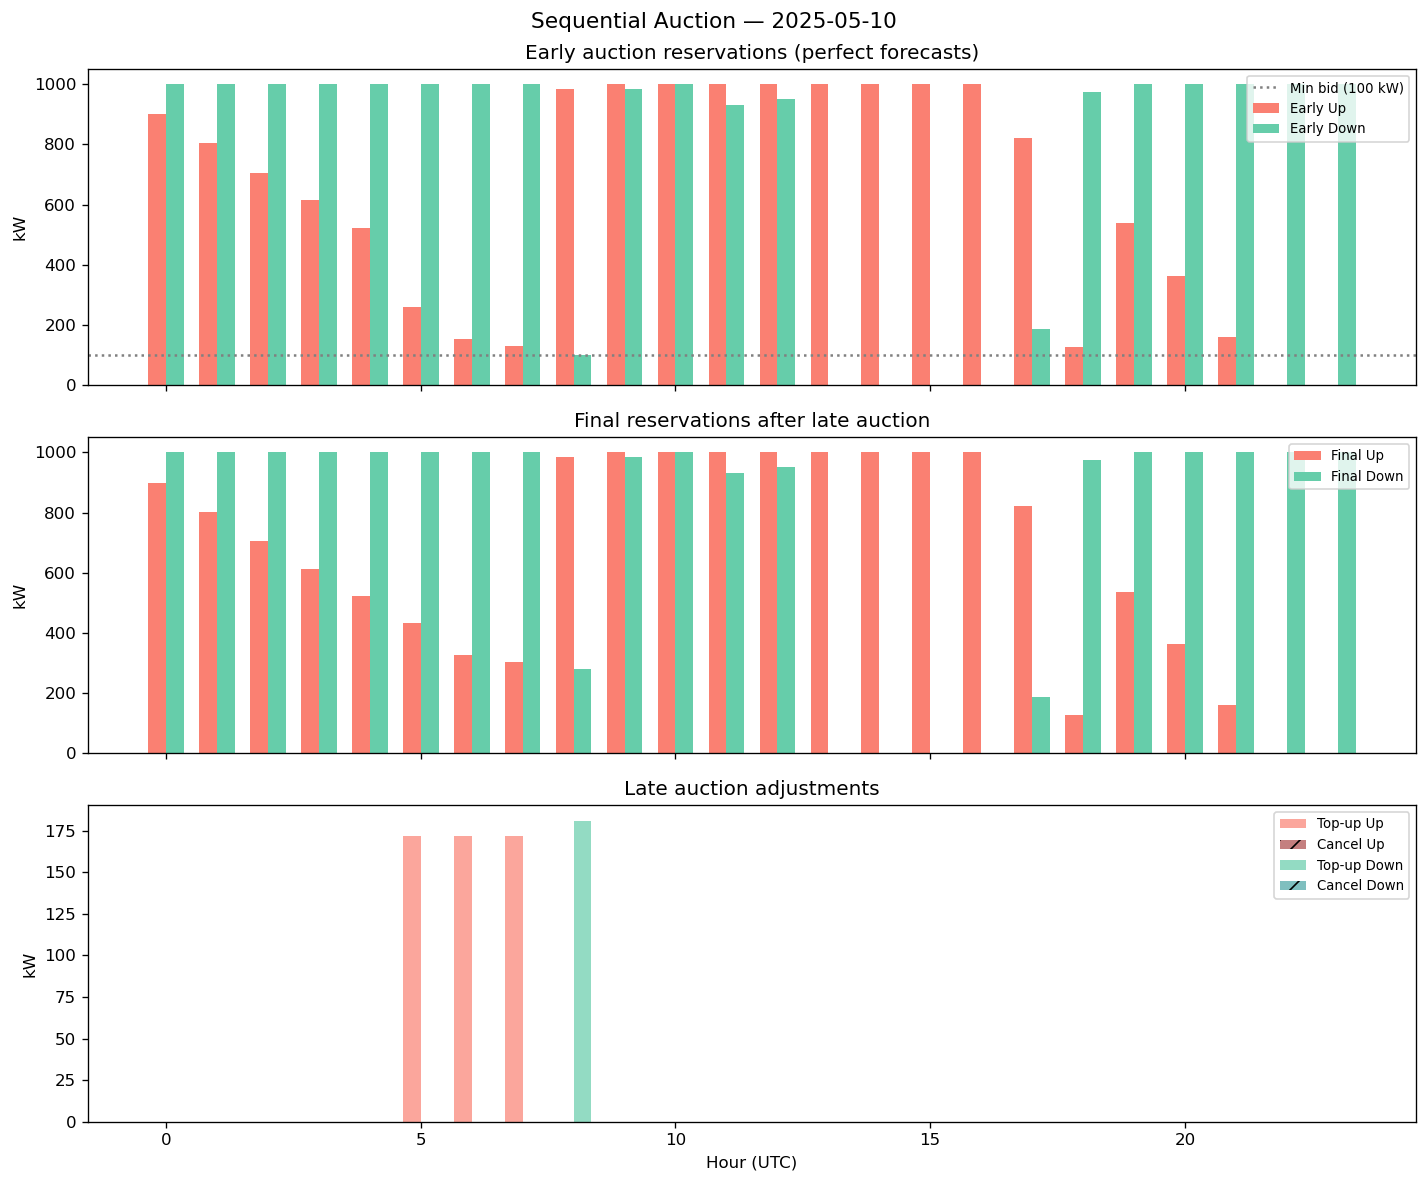

In [13]:
# ── Figure 4: Sequential auction reservations ────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle(f'Sequential Auction — {example_date}', fontsize=13)
w = 0.35

ax = axes[0]; ax.set_title('Early auction reservations (perfect forecasts)')
ax.bar(hours-w/2, res['early_up_res'], w, color='salmon', label='Early Up')
ax.bar(hours+w/2, res['early_dn_res'], w, color='mediumaquamarine', label='Early Down')
ax.axhline(P_MIN_BID, color='grey', ls=':', label=f'Min bid ({P_MIN_BID} kW)')
ax.set_ylabel('kW'); ax.legend(fontsize=8)

ax = axes[1]; ax.set_title('Final reservations after late auction')
ax.bar(hours-w/2, res['final_up_res'], w, color='salmon', label='Final Up')
ax.bar(hours+w/2, res['final_dn_res'], w, color='mediumaquamarine', label='Final Down')
ax.set_ylabel('kW'); ax.legend(fontsize=8)

ax = axes[2]; ax.set_title('Late auction adjustments')
ax.bar(hours-w/2, res['topup_up'], w, color='salmon', alpha=0.7, label='Top-up Up')
ax.bar(hours-w/2, -res['cancel_up'], w, color='darkred', alpha=0.5, label='Cancel Up', hatch='//')
ax.bar(hours+w/2, res['topup_dn'], w, color='mediumaquamarine', alpha=0.7, label='Top-up Down')
ax.bar(hours+w/2, -res['cancel_dn'], w, color='teal', alpha=0.5, label='Cancel Down', hatch='//')
ax.set_ylabel('kW'); ax.set_xlabel('Hour (UTC)'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'reservations1.png'), dpi=150, bbox_inches='tight')
plt.show()

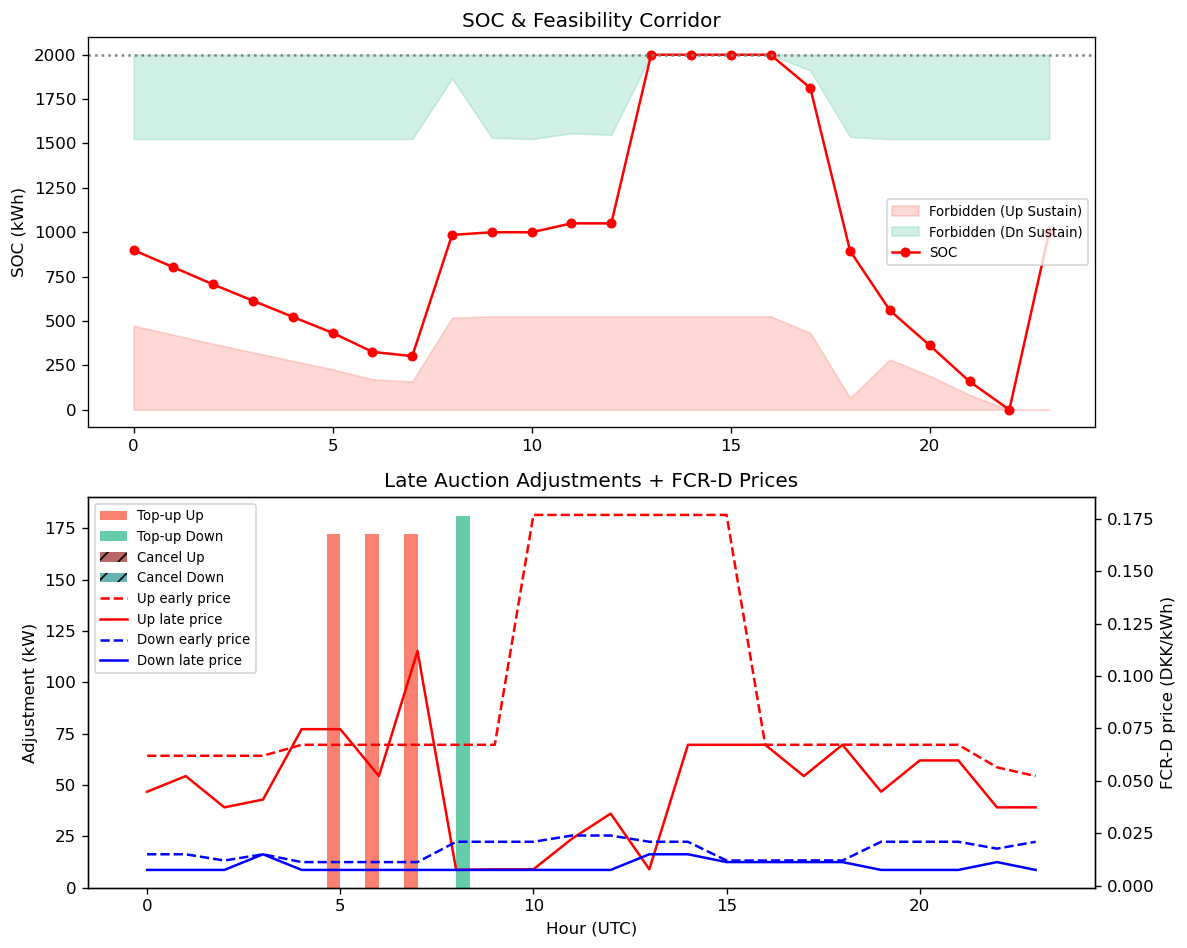

In [14]:
# ── Figure 5: SOC & Feasibility Corridor ─────────────────────────────────
ya_u = df_day['y_acc_up'].values
ya_d = df_day['y_acc_down'].values
forb_up = ya_u * T_SUSTAIN / ETA * res['final_up_res']
forb_dn = ya_d * T_SUSTAIN * ETA * res['final_dn_res']

up_e = df_day[COL_UP_EARLY].values
up_l = df_day[COL_UP_LATE].values
dn_e = df_day[COL_DOWN_EARLY].values
dn_l = df_day[COL_DOWN_LATE].values

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

ax = axes[0]; ax.set_title('SOC & Feasibility Corridor')
ax.fill_between(hours, 0, forb_up, alpha=0.3, color='salmon', label='Forbidden (Up Sustain)')
ax.fill_between(hours, S_MAX_PORTFOLIO-forb_dn, S_MAX_PORTFOLIO,
                alpha=0.3, color='mediumaquamarine', label='Forbidden (Dn Sustain)')
ax.plot(hours, res['soc'], 'r-o', ms=5, label='SOC')
ax.axhline(S_MAX_PORTFOLIO, color='grey', ls=':')
ax.set_ylabel('SOC (kWh)'); ax.legend(fontsize=8)

ax = axes[1]; ax.set_title('Late Auction Adjustments + FCR-D Prices')
ax.bar(hours-w/2, res['topup_up'], w, color='salmon', label='Top-up Up')
ax.bar(hours+w/2, res['topup_dn'], w, color='mediumaquamarine', label='Top-up Down')
ax.bar(hours-w/2, -res['cancel_up'], w, color='darkred', alpha=0.6, label='Cancel Up', hatch='//')
ax.bar(hours+w/2, -res['cancel_dn'], w, color='teal', alpha=0.6, label='Cancel Down', hatch='//')
ax.set_ylabel('Adjustment (kW)')
ax.set_xlabel('Hour (UTC)')

ax2 = ax.twinx()
ax2.plot(hours, up_e, 'r--', lw=1.5, label='Up early price')
ax2.plot(hours, up_l, 'r-',  lw=1.5, label='Up late price')
ax2.plot(hours, dn_e, 'b--', lw=1.5, label='Down early price')
ax2.plot(hours, dn_l, 'b-',  lw=1.5, label='Down late price')
ax2.set_ylabel('FCR-D price (DKK/kWh)')

handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles + handles2, labels + labels2, fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'dashboard2.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Full year back-test (2025, perfect forecasts)

Run the sequential early + late auction MILP for every day.
This produces the **upper bound** on revenue.

In [15]:
# Complete 24h days only
day_counts = df_all.groupby('date').size()
complete_dates = sorted([d for d, c in day_counts.items() if c == 24])
print(f'Days to solve: {len(complete_dates)}')

Days to solve: 365


In [16]:
results_list = []
failed_days  = []

t0 = time.time()
for i, dv in enumerate(complete_dates):
    try:
        dd = df_all[df_all['date'] == dv].sort_values('hour_utc').reset_index(drop=True)
        ld, pv = get_ec_profiles(dd, ec_types, scale_factors)
        r = solve_day(dv, dd, ld, pv, run_base=True)
        results_list.append(r)
        if (i+1) % 30 == 0 or (i+1) == len(complete_dates):
            print(f'  [{i+1:>3}/{len(complete_dates)}] {dv}  '
                  f'FCRD={r["total_fcrd_rev"]:>8.1f}  elapsed={time.time()-t0:.0f}s')
    except Exception as ex:
        failed_days.append((dv, str(ex)))
        print(f'  FAILED {dv}: {ex}')

print(f'\nDone: {len(results_list)} solved, {len(failed_days)} failed in {time.time()-t0:.0f}s')

KeyboardInterrupt: 

In [ ]:
# ── Build results DataFrame ──────────────────────────────────────────────
scalar_keys = ['date','net_energy_cost','import_cost','export_rev',
               'fcrd_up_early_rev','fcrd_dn_early_rev',
               'fcrd_up_late_rev','fcrd_dn_late_rev',
               'buyback_up_cost','buyback_dn_cost',
               'fcrd_up_net','fcrd_dn_net','total_fcrd_rev',
               'base_energy_cost','no_battery_cost']

df_res = pd.DataFrame([{k: r[k] for k in scalar_keys if k in r} for r in results_list])
df_res['date'] = pd.to_datetime(df_res['date'])
df_res['month'] = df_res['date'].dt.month

df_res['batt_arb_saving']     = df_res['no_battery_cost'] - df_res['base_energy_cost']
df_res['arb_improvement_fcrd']= df_res['base_energy_cost'] - df_res['net_energy_cost']
df_res['total_value']         = (df_res['batt_arb_saving']
                                 + df_res['arb_improvement_fcrd']
                                 + df_res['total_fcrd_rev'])

print(df_res[['date','batt_arb_saving','arb_improvement_fcrd',
              'fcrd_up_net','fcrd_dn_net','total_value']].describe())

## 10. Yearly revenue summary (Table 3)

In [ ]:
tot = df_res[['batt_arb_saving','arb_improvement_fcrd',
              'fcrd_up_net','fcrd_dn_net','total_value']].sum()

print('=' * 55)
print(f'{"Revenue stream":<35} {"Value (TDKK)":>15}')
print('-' * 55)
print(f'{"Battery arbitrage saving":<35} {tot.batt_arb_saving/1000:>15.1f}')
print(f'{"Arb improvement from FCR-D":<35} {tot.arb_improvement_fcrd/1000:>15.1f}')
print(f'{"FCR-D Up net revenue":<35} {tot.fcrd_up_net/1000:>15.1f}')
print(f'{"FCR-D Down net revenue":<35} {tot.fcrd_dn_net/1000:>15.1f}')
print('-' * 55)
print(f'{"Total value":<35} {tot.total_value/1000:>15.1f}')
fcrd_share = (tot.fcrd_up_net + tot.fcrd_dn_net) / tot.total_value * 100
print(f'{"FCR-D share of total":<35} {fcrd_share:>14.1f}%')
print(f'{"Battery arb share of total":<35} {tot.batt_arb_saving/tot.total_value*100:>14.1f}%')
print('=' * 55)

## 11. Yearly plots (Figures 6 & 7)

In [ ]:
mo = df_res.groupby('month').sum(numeric_only=True).reset_index()
mlbl = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
mx = mo['month'].values

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f'Sequential FCR-D — {N_EC} ECs ({P_MAX_PORTFOLIO} kW / {S_MAX_PORTFOLIO} kWh)', fontsize=13)

ax = axes[0,0]; ax.set_title('Monthly arbitrage cost by strategy')
w = 0.25
ax.bar(mx-w, mo['no_battery_cost']/1000, w, label='No battery', color='lightgrey')
ax.bar(mx,   mo['base_energy_cost']/1000, w, label='Base (batt only)', color='steelblue')
ax.bar(mx+w, mo['net_energy_cost']/1000, w, label='Early+Late', color='darkblue')
ax.set_ylabel('Net cost (TDKK)'); ax.set_xticks(range(1,13)); ax.set_xticklabels(mlbl, fontsize=7)
ax.legend(fontsize=7)

ax = axes[0,1]; ax.set_title('Monthly FCR-D revenue decomposition')
er = (mo['fcrd_up_early_rev']+mo['fcrd_dn_early_rev'])/1000
tr = (mo['fcrd_up_late_rev']+mo['fcrd_dn_late_rev'])/1000
cc = (mo['buyback_up_cost']+mo['buyback_dn_cost'])/1000
ax.bar(mx, er, label='Early rev', color='salmon')
ax.bar(mx, tr, bottom=er, label='Top-up rev', color='mediumaquamarine')
ax.bar(mx, -cc, label='Cancel cost', color='darkred', alpha=0.6)
ax.set_ylabel('TDKK'); ax.set_xticks(range(1,13)); ax.set_xticklabels(mlbl, fontsize=7)
ax.legend(fontsize=7)

ax = axes[1,0]; ax.set_title('Monthly late-auction value')
late_net = (mo['fcrd_up_late_rev']+mo['fcrd_dn_late_rev']
            -mo['buyback_up_cost']-mo['buyback_dn_cost'])/1000
ax.bar(mx, late_net, color='teal')
ax.set_ylabel('Uplift (TDKK)'); ax.set_xticks(range(1,13)); ax.set_xticklabels(mlbl, fontsize=7)

ax = axes[1,1]; ax.set_title('Monthly total value')
ax.bar(mx, mo['total_value']/1000, color='goldenrod')
ax.set_ylabel('TDKK'); ax.set_xticks(range(1,13)); ax.set_xticklabels(mlbl, fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'YearlyRun.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Figure 7: Revenue stream breakdown ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title(f'Monthly revenue streams — {N_EC} ECs ({P_MAX_PORTFOLIO} kW / {S_MAX_PORTFOLIO} kWh)')

w = 0.18
ax.bar(mx-1.5*w, mo['batt_arb_saving']/1000, w, label='Battery arb saving', color='steelblue')
ax.bar(mx-0.5*w, mo['arb_improvement_fcrd']/1000, w, label='Arb improvement (FCR-D)', color='lightblue')
ax.bar(mx+0.5*w, mo['fcrd_up_net']/1000, w, label='FCR-D Up net', color='salmon')
ax.bar(mx+1.5*w, mo['fcrd_dn_net']/1000, w, label='FCR-D Down net', color='mediumaquamarine')
ax.plot(mx, mo['total_value']/1000, 'k-o', ms=5, label='Total value')

ax.set_ylabel('Value (TDKK)'); ax.set_xticks(range(1,13)); ax.set_xticklabels(mlbl)
ax.legend(fontsize=9); ax.axhline(0, color='grey', lw=0.5)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'YearlyRevBreakdown.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Save results

In [ ]:
output_csv = os.path.join(DATA_OUT_DIR, 'backtest_upper_bound_2025.csv')
df_res.to_csv(output_csv, index=False)
print(f'Saved: {output_csv}')
print(f'Total value: {df_res["total_value"].sum()/1000:.1f} TDKK')
print(f'FCR-D share: {(df_res["fcrd_up_net"].sum()+df_res["fcrd_dn_net"].sum())/df_res["total_value"].sum()*100:.1f}%')